
 Mutation Analysis Summary:

M1 | Connections: 4 | Influence: 8 | Degree Centrality: 1.00 | Betweenness: 0.17
M2 | Connections: 4 | Influence: 10 | Degree Centrality: 1.00 | Betweenness: 0.17
M3 | Connections: 3 | Influence: 7 | Degree Centrality: 0.75 | Betweenness: 0.00
M4 | Connections: 3 | Influence: 7 | Degree Centrality: 0.75 | Betweenness: 0.00
M5 | Connections: 2 | Influence: 2 | Degree Centrality: 0.50 | Betweenness: 0.00

 Most Influential Mutation: M2


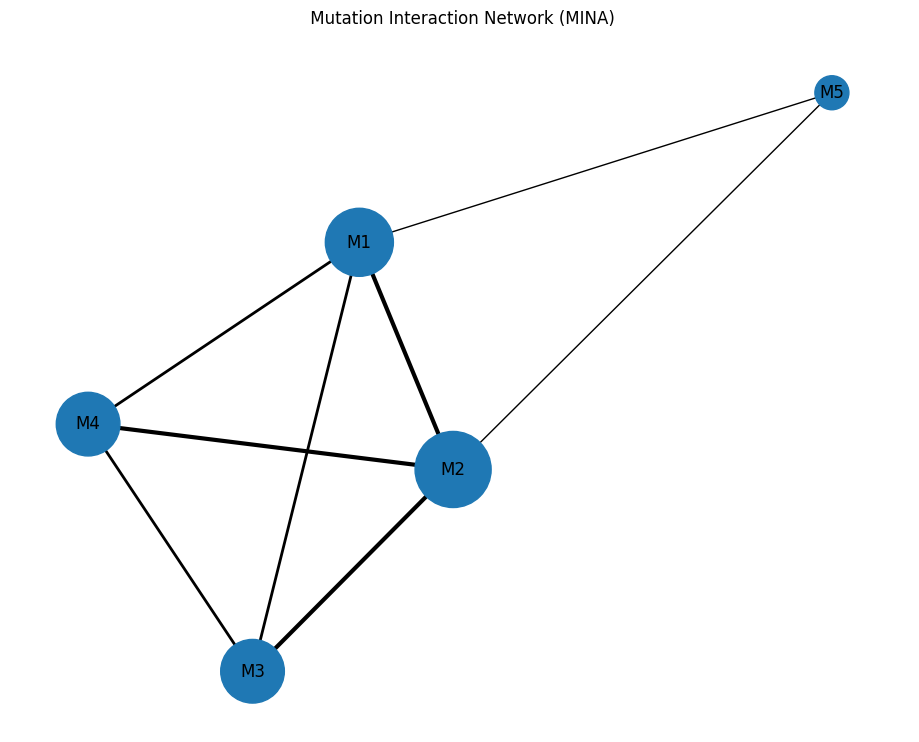

In [1]:
# ============================================
#  Mutation Interaction Network Analyzer (MINA)
# ============================================

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

# -----------------------------
# STEP 1: SAMPLE DATASET
# -----------------------------
data = [
    ['M1', 'M2', 'M3'],
    ['M1', 'M2'],
    ['M2', 'M3'],
    ['M1', 'M3'],
    ['M1', 'M2', 'M4'],
    ['M2', 'M4'],
    ['M3', 'M4'],
    ['M1', 'M4'],
    ['M2', 'M3', 'M4'],
    ['M1', 'M5'],
    ['M5', 'M2']
]

df = pd.DataFrame({'Mutations': data})

# -----------------------------
# STEP 2: BUILD NETWORK
# -----------------------------
G = nx.Graph()

for row in df['Mutations']:
    for m in row:
        G.add_node(m)
    for combo in combinations(row, 2):
        if G.has_edge(*combo):
            G[combo[0]][combo[1]]['weight'] += 1
        else:
            G.add_edge(combo[0], combo[1], weight=1)

# -----------------------------
# STEP 3: ANALYSIS
# -----------------------------
# Degree (connections)
degree = dict(G.degree())

# Influence Score (weighted interactions)
influence = {
    node: sum(G[node][nbr]['weight'] for nbr in G.neighbors(node))
    for node in G.nodes()
}

# Centrality Measures
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

# Most influential mutation
top_mutation = max(influence, key=influence.get)

# -----------------------------
# STEP 4: OUTPUT RESULTS
# -----------------------------
print("\n Mutation Analysis Summary:\n")

for node in G.nodes():
    print(f"{node} | Connections: {degree[node]} | "
          f"Influence: {influence[node]} | "
          f"Degree Centrality: {degree_centrality[node]:.2f} | "
          f"Betweenness: {betweenness_centrality[node]:.2f}")

print(f"\n Most Influential Mutation: {top_mutation}")

# -----------------------------
# STEP 5: VISUALIZATION
# -----------------------------
plt.figure(figsize=(9,7))

pos = nx.spring_layout(G, seed=42)

# Node size based on influence
node_sizes = [influence[node]*300 for node in G.nodes()]

# Edge thickness based on weight
weights = [G[u][v]['weight'] for u,v in G.edges()]

nx.draw(
    G, pos,
    with_labels=True,
    node_size=node_sizes,
    width=weights
)

plt.title(" Mutation Interaction Network (MINA)")
plt.show()